In [21]:
%pip install pandas torch transformers deepparse huggingface_hub matplotlib ipympl rdflib
%matplotlib inline

Note: you may need to restart the kernel to use updated packages.


In [22]:
import torch
if torch.cuda.is_available():
    print("CUDA - available devices:")
    for i in range(torch.cuda.device_count()):
        print(f"  {i}: {torch.cuda.get_device_name(i)}")
    device = torch.device('cuda')
elif torch.accelerator.is_available(): # Support other hardware accelators
    device = torch.accelerator.current_accelerator()
else:
    print("WARNING: Running on CPU")
    device = torch.device('cpu')
print(f"Torch version: {torch.__version__}, Device: {device}")

CUDA - available devices:
  0: NVIDIA A100 80GB PCIe
  1: NVIDIA A100 80GB PCIe
Torch version: 2.10.0+cu128, Device: cuda


In [23]:
from huggingface_hub import notebook_login
notebook_login()

In [24]:
from collections import OrderedDict
import pandas as pd
import json

COLS_TO_PREDICT = [
    "HouseNumber",
    "StreetName",
    "City",
    "State",
    "Country"
]
bzkopen_val = pd.read_csv("open_data/bzkopen_addresses_val.csv")
bzkopen_test = pd.read_csv("open_data/bzkopen_addresses_test.csv")

EXAMPLES = [
    ("Berlin, Alexanderplatz 1, 10178", 
     OrderedDict([("City" , "Berlin"), ("StreetName", "Alexanderplatz"), ("HouseNumber", "1")])),
    ("Braunschweig, Uferstr. 25", # From BZK open training set
     OrderedDict([("City", "Braunschweig"), ("StreetName", "Uferstr."), ("HouseNumber", "25")])),
    ("808 Westend Avenue, New York 25, N.Y.", # From BZK open training set
        OrderedDict([("StreetName", "Westend Avenue"), ("HouseNumber", "808"), 
        ("City", "New York"), ("State", "N.Y.")])),
]



In [25]:

from mllms import JsonDictPromptTemplate, JSONTuplesPromptTemplate


PROMPTS = [
    JsonDictPromptTemplate("Segment addresses into their components.\n"
    "Output only a JSON object with the following keys: " + ", ".join(COLS_TO_PREDICT) + ". "
    "Do not include fields that cannot be determined and do not try to guess their values. "
    "For example, if the address is simply \"Berlin\" then the field \"Country\" should be null. "
    "Addresses will most times be written in german, meaning country and city names may be in "
    "german and the addresses "
    "may include german terms such as:\n"
    " - \"burg\" or \"stadt\" for city\n"
    " - \"straße\" or its abbreviation \"str.\" for street.\n"
    "These terms may occur as a suffix to another word.\n%(examples)s"
    "Now segment the following address:\n%(address)s"),

    JSONTuplesPromptTemplate("Annotate address components with the respective types. "
    "Consider the component types: " + ", ".join(COLS_TO_PREDICT + ["Other"]) + ". "
    "Not all addresses will contain all component types and you must not guess the missing ones. "
    "Addresses will most times be written in german, meaning country and city names may be in "
    "german and the addresses "
    "may include german terms such as:\n"
    " - \"burg\" or \"stadt\" for city\n"
    " - \"straße\" or its abbreviation \"str.\" for street.\n"
    "These terms may occur as a suffix to another word.\n"
    "Output only a JSON list of [component, type] tuples.\n%(examples)s"
    "Now annotate the following address:\n%(address)s"),
]



for i, prompt in enumerate(PROMPTS):
    print(f"Prompt {i}:")
    print(prompt.template)
    print()

Prompt 0:
Segment addresses into their components.
Output only a JSON object with the following keys: HouseNumber, StreetName, City, State, Country. Do not include fields that cannot be determined and do not try to guess their values. For example, if the address is simply "Berlin" then the field "Country" should be null. Addresses will most times be written in german, meaning country and city names may be in german and the addresses may include german terms such as:
 - "burg" or "stadt" for city
 - "straße" or its abbreviation "str." for street.
These terms may occur as a suffix to another word.
%(examples)sNow segment the following address:
%(address)s

Prompt 1:
Annotate address components with the respective types. Consider the component types: HouseNumber, StreetName, City, State, Country, Other. Not all addresses will contain all component types and you must not guess the missing ones. Addresses will most times be written in german, meaning country and city names may be in german 

In [26]:
from deepparse_parser import DeepParseParser
from libpostal_client import LibpostalClient
from llm_token_classifiers import TokenClassifierAddressParser
from mllms import LlamaAddressParsingModel, FixedExamples, ZeroShot
from itertools import combinations
import time
from pathlib import Path
from utils import compare_preds

model_configs = [
    {
        "name" : "libpostal",
        "factory": LibpostalClient,
        "cleanup": lambda client: client.close(),
    },
    {
        "name" : "libpostal-expanded",
        "factory": LibpostalClient,
        "factory_kargs" : {"expand_before_parsing": True},
        "cleanup": lambda client: client.close(),
    },
    {
        "name" : "deepparse-bpemb",
        "factory": DeepParseParser,
        "factory_kargs": {"model_type": "bpemb", "device": device}
    },
    {
        "name" : "deepparse-fasttext",
        "factory": DeepParseParser,
        "factory_kargs": {"model_type": "fasttext", "device": device}
    },
    {
        "name" : "deepparse-bpemb-attention",
        "factory": DeepParseParser,
        "factory_kargs": {"model_type": "bpemb", "attention_mechanism": True, "device": device}
    },
    {
        "name" : "deepparse-fasttext-attention",
        "factory": DeepParseParser,
        "factory_kargs": {"model_type": "fasttext", "attention_mechanism": True, "device": device}
    },
    {
         "name" : "xlm-roberta-large-address-parser", # from https://arxiv.org/abs/2404.05632
         "factory": TokenClassifierAddressParser,
         "factory_kargs": {"model_name" : "hm-haitham/xlm-roberta-large-address-parser", "device": device}
    },
    {
         "name" : "xlm-roberta-large-address-parser-word-avg",
         "factory": TokenClassifierAddressParser,
         "factory_kargs": {"model_name" : "hm-haitham/xlm-roberta-large-address-parser", "device": device, "aggregation_strategy": "average"}
    },
    {
         "name" : "xlm-roberta-large-address-parser-word-max",
         "factory": TokenClassifierAddressParser,
         "factory_kargs": {"model_name" : "hm-haitham/xlm-roberta-large-address-parser", "device": device, "aggregation_strategy": "max"}
    }
]

LLAMA_MODELS = [
    ("Llama-3.2-1B", "meta-llama/Llama-3.2-1B-Instruct"),
    ("Llama-3.2-3B", "meta-llama/Llama-3.2-3B-Instruct")
]

example_strategies = [
    ("0shot", ZeroShot())
]

for nshots in [1, 2]:
    for example_indices in combinations(range(len(EXAMPLES)), nshots):
        example_strategies.append((
             f"fixed{nshots}shot-ex{''.join(str(i) for i in example_indices)}", 
             FixedExamples([EXAMPLES[i] for i in example_indices])
        ))

example_strategies.append(("fixed3shot", FixedExamples(EXAMPLES)))

n_shot_model_configs = []

for example_strategy_id, example_strategy in example_strategies:
    for model_id, model_name in LLAMA_MODELS:
        for prompt_id, prompt in enumerate(PROMPTS):
                config_name = f"{model_id}-prompt{prompt_id}-{example_strategy_id}"
                n_shot_model_configs.append({
                    "name": config_name,
                    "factory": LlamaAddressParsingModel,
                    "factory_kargs" : {
                        "model_name": model_name,
                        "prompt": prompt,
                        "example_strategy": example_strategy,
                        "device": device
                    }
                })

model_configs.extend(config for config in n_shot_model_configs if config["name"].endswith("3shot"))

for config in model_configs:
    print(f"Model config: {repr(config)}")


Model config: {'name': 'libpostal', 'factory': <class 'libpostal_client.LibpostalClient'>, 'cleanup': <function <lambda> at 0x7f08a2b05c60>}
Model config: {'name': 'libpostal-expanded', 'factory': <class 'libpostal_client.LibpostalClient'>, 'factory_kargs': {'expand_before_parsing': True}, 'cleanup': <function <lambda> at 0x7f08a2b071a0>}
Model config: {'name': 'deepparse-bpemb', 'factory': <class 'deepparse_parser.DeepParseParser'>, 'factory_kargs': {'model_type': 'bpemb', 'device': device(type='cuda')}}
Model config: {'name': 'deepparse-fasttext', 'factory': <class 'deepparse_parser.DeepParseParser'>, 'factory_kargs': {'model_type': 'fasttext', 'device': device(type='cuda')}}
Model config: {'name': 'deepparse-bpemb-attention', 'factory': <class 'deepparse_parser.DeepParseParser'>, 'factory_kargs': {'model_type': 'bpemb', 'attention_mechanism': True, 'device': device(type='cuda')}}
Model config: {'name': 'deepparse-fasttext-attention', 'factory': <class 'deepparse_parser.DeepParsePars

In [27]:
import traceback

def eval(dataset, configs, cols_to_predict, pred_cache_path=None):
    if pred_cache_path is not None:
        pred_cache_path = Path(pred_cache_path)
    if pred_cache_path is None or not pred_cache_path.exists():
        cached_preds = {}
    else:
        print(f"Loading cached predictions...")
        with open(pred_cache_path, "r") as f:
            cached_preds = json.load(f)
    
    preds_per_config = []
    model_results = []

    for config in configs:
        config_name = config["name"]
        if config_name in cached_preds:
            print(f"Using cached predictions for model {config_name}... To avoid this delete or rename the file {pred_cache_path} or delete the entry for {config_name} inside it.")
            preds = cached_preds[config_name]["preds"]
            deltatime = cached_preds[config_name]["deltatime"]
        else:
            try:
                print(f"Loading model {config_name}...")
                pargs = config.get("factory_pargs", [])
                kargs = config.get("factory_kargs", {})
                model = config["factory"](*pargs, **kargs)
                print(f"Segmenting addresses...")
                start = time.monotonic()
                preds = model.parse_addresses(dataset["FullAddress"].tolist())
                deltatime = time.monotonic() - start
                if "cleanup" in config:
                    print("Cleaning up model resources...")
                    config["cleanup"](model)
                print("Parsing model responses...")
                if pred_cache_path is not None:
                    cached_preds[config_name] = {
                        "preds": preds,
                        "deltatime": deltatime
                    }
            except Exception as e:
                print(f"Error while processing model {config_name}: {e}")
                traceback.print_exc()
                model_results.append({
                    "error" : len(dataset),
                    "errorRate" : 1.0
                })
                continue
        preds_df = pd.DataFrame(preds)
        preds_per_config.append(preds_df)
        print("Computing metrics...")
        metrics = compare_preds(preds_df, dataset[cols_to_predict], target_columns=cols_to_predict)
        metrics["deltatime"] = deltatime
        metrics["rate"] = len(dataset) / metrics["deltatime"]
        metrics["error"] = preds_df["error"].notna().sum() if "error" in preds_df.columns else 0
        metrics["errorRate"] = metrics["error"] / len(dataset)
        preds_df["config_name"] = config_name
        preds_df["FullAddress"] = dataset["FullAddress"]

        model_results.append(metrics)
        print(f"Results for model {config_name}: {metrics}")

    if pred_cache_path is not None:
        with open(pred_cache_path, "w") as f:
            json.dump(cached_preds, f)

    preds_per_config_df = pd.concat(preds_per_config)
    default_cols = ["config_name", "FullAddress"] + cols_to_predict
    new_order = default_cols + [col for col in preds_per_config_df.columns if col not in default_cols]
    preds_per_config_df = preds_per_config_df[new_order]

    results_df = pd.DataFrame(model_results, index = [config["name"] for config in configs])
    return preds_per_config_df, results_df



preds_per_config, model_statistics = eval(bzkopen_val, model_configs, COLS_TO_PREDICT, pred_cache_path="cached_preds_val.json")

model_statistics[["accuracy", "precision", "recall", "f1", "average_similarity", "errorRate", "rate"]]

Loading cached predictions...
Using cached predictions for model libpostal... To avoid this delete or rename the file cached_preds_val.json or delete the entry for libpostal inside it.
Computing metrics...
Results for model libpostal: OrderedDict({'accuracy': 0.7651515151515151, 'precision': 0.650887573964497, 'recall': 0.44534412955465585, 'f1': 0.5288461538461539, 'accuracy_with_tol_1': 0.7712121212121212, 'accuracy_with_tol_2': 0.7772727272727272, 'accuracy_with_tol_3': 0.7833333333333333, 'accuracy_with_tol_4': 0.8136363636363636, 'average_levenshtein': 1.7454545454545454, 'average_similarity': 0.7890700578111242, 'average_levenshtein_match': 2.1215469613259668, 'average_similarity_match': 0.9590906780024714, 'no_match_rate': 0.17727272727272725, 'deltatime': 0.03200000000651926, 'rate': 4124.999999159627, 'error': 0, 'errorRate': 0.0})
Using cached predictions for model libpostal-expanded... To avoid this delete or rename the file cached_preds_val.json or delete the entry for libp

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

/home/rpatroni/bzk-post-processing/llm_token_classifiers.py:151: UserWarning: Tokenizer is not word aware and aggregation strategy average requires word awareness. Modifying transformers pipeline implementation to support it. This will likely break accross transformers library updates.
  warnings.warn(


Segmenting addresses...


/home/rpatroni/bzk-post-processing/llm_token_classifiers.py:98: UserWarning: Tokenizer does not support real words, using fallback heuristic
  warnings.warn(


...

/home/rpatroni/bzk-post-processing/llm_token_classifiers.py:151: UserWarning: Tokenizer is not word aware and aggregation strategy max requires word awareness. Modifying transformers pipeline implementation to support it. This will likely break accross transformers library updates.
  warnings.warn(


Segmenting addresses...


/home/rpatroni/bzk-post-processing/llm_token_classifiers.py:98: UserWarning: Tokenizer does not support real words, using fallback heuristic
  warnings.warn(


Parsing model responses...
Computing metrics...
Results for model xlm-roberta-large-address-parser-word-max: OrderedDict({'accuracy': 0.8287878787878787, 'precision': 0.6437768240343348, 'recall': 0.6072874493927125, 'f1': 0.625, 'accuracy_with_tol_1': 0.8348484848484848, 'accuracy_with_tol_2': 0.8409090909090909, 'accuracy_with_tol_3': 0.8545454545454545, 'accuracy_with_tol_4': 0.8666666666666667, 'average_levenshtein': 1.2196969696969697, 'average_similarity': 0.8571771258302006, 'average_levenshtein_match': 1.3327814569536425, 'average_similarity_match': 0.9366505017349874, 'no_match_rate': 0.08484848484848484, 'deltatime': 0.23429039120674133, 'rate': 563.4033872243665, 'error': 0, 'errorRate': 0.0})
Using cached predictions for model Llama-3.2-1B-prompt0-fixed3shot... To avoid this delete or rename the file cached_preds_val.json or delete the entry for Llama-3.2-1B-prompt0-fixed3shot inside it.
Computing metrics...
Results for model Llama-3.2-1B-prompt0-fixed3shot: OrderedDict({'a

,accuracy,precision,recall,f1,average_similarity,errorRate,rate
libpostal,0.765152,0.650888,0.445344,0.528846,0.789070,0.000000,4124.999999
libpostal-expanded,0.769697,0.578125,0.449393,0.505695,0.818799,0.000000,4258.064514
deepparse-bpemb,0.459091,0.293839,0.251012,0.270742,0.512745,0.000000,458.657079
deepparse-fasttext,0.498485,0.360000,0.327935,0.343220,0.551947,0.000000,4088.926064
deepparse-bpemb-attention,0.363636,0.084270,0.060729,0.070588,0.395304,0.000000,1269.106457
deepparse-fasttext-attention,0.322727,0.141700,0.141700,0.141700,0.355795,0.000000,2563.911700
xlm-roberta-large-address-parser,0.819697,0.610656,0.603239,0.606925,0.854149,0.000000,199.160903
xlm-roberta-large-address-parser-word-avg,0.833333,0.645570,0.619433,0.632231,0.861791,0.000000,230.835029
xlm-roberta-large-address-parser-word-max,0.828788,0.643777,0.607287,0.625000,0.857177,0.000000,563.403387
Llama-3.2-1B-prompt0-fixed3shot,0.500000,0.344498,0.582996,0.433083,0.521729,0.045455,8.382107


In [28]:
preds_per_config

,config_name,FullAddress,HouseNumber,StreetName,City,State,Country,house,state_district,unit,...,StreetNamePrefixes,CitySuffix,Region/Province,Direction,StreetNumber,Building,Postal,Province,City/State,StreetName/Other
0,libpostal,"Regensburg, Königstr. 2/I",2/i,königstr.,NaN,NaN,NaN,regensburg,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,libpostal,Dortmund,NaN,NaN,dortmund,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,libpostal,Jöhlingen/Krs. Durlach/Baden.,NaN,NaN,NaN,NaN,NaN,jöhlingen/krs. durlach/baden.,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,libpostal,"8 Burlington Road, Manchester 20/England.",8___20/england.,burlington road manchester,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,libpostal,Leer/Ostfriesland,NaN,NaN,NaN,NaN,NaN,NaN,leer/ostfriesland,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,Llama-3.2-3B-prompt1-fixed3shot,Sosnowice/Polen,NaN,NaN,Sosnowice,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
128,Llama-3.2-3B-prompt1-fixed3shot,2114-79 St. Jackson Heights. N.Y. USA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
129,Llama-3.2-3B-prompt1-fixed3shot,Losone CSR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
130,Llama-3.2-3B-prompt1-fixed3shot,Rum.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
preds_per_nshots, model_statistics_nshots = eval(bzkopen_val, n_shot_model_configs, COLS_TO_PREDICT, pred_cache_path="cached_nshot_preds_val.json")
model_statistics_nshots[["accuracy", "precision", "recall", "f1", "errorRate", "rate"]]

Loading cached predictions...
Using cached predictions for model Llama-3.2-1B-prompt0-0shot... To avoid this delete or rename the file cached_nshot_preds_val.json or delete the entry for Llama-3.2-1B-prompt0-0shot inside it.
Computing metrics...
Results for model Llama-3.2-1B-prompt0-0shot: OrderedDict({'accuracy': 0.39090909090909093, 'precision': 0.30368098159509205, 'recall': 0.4008097165991903, 'f1': 0.3455497382198953, 'accuracy_with_tol_1': 0.4, 'accuracy_with_tol_2': 0.403030303030303, 'accuracy_with_tol_3': 0.41515151515151516, 'accuracy_with_tol_4': 0.45606060606060606, 'average_levenshtein': 3.533333333333333, 'average_similarity': 0.4120175290656222, 'average_levenshtein_match': 6.9243421052631575, 'average_similarity_match': 0.8945117407345746, 'no_match_rate': 0.5393939393939393, 'deltatime': 10.00659503787756, 'rate': 13.19130028749497, 'error': 5, 'errorRate': 0.03787878787878788})
Using cached predictions for model Llama-3.2-1B-prompt1-0shot... To avoid this delete or r

,accuracy,precision,recall,f1,errorRate,rate
Llama-3.2-1B-prompt0-0shot,0.390909,0.303681,0.400810,0.345550,0.037879,13.191300
Llama-3.2-1B-prompt1-0shot,0.568182,0.146341,0.048583,0.072948,0.265152,7.194152
Llama-3.2-3B-prompt0-0shot,0.742424,0.546468,0.595142,0.569767,0.083333,5.311129
Llama-3.2-3B-prompt1-0shot,0.645455,0.536585,0.089069,0.152778,0.553030,4.866086
Llama-3.2-1B-prompt0-fixed1shot-ex0,0.607576,0.397163,0.453441,0.423440,0.053030,9.064516
Llama-3.2-1B-prompt1-fixed1shot-ex0,0.746970,0.529412,0.546559,0.537849,0.060606,7.628205
Llama-3.2-3B-prompt0-fixed1shot-ex0,0.774242,0.593640,0.680162,0.633962,0.045455,4.773487
Llama-3.2-3B-prompt1-fixed1shot-ex0,0.801515,0.687500,0.578947,0.628571,0.053030,4.751141
Llama-3.2-1B-prompt0-fixed1shot-ex1,0.554545,0.369822,0.506073,0.427350,0.022727,8.728592
Llama-3.2-1B-prompt1-fixed1shot-ex1,0.768182,0.591837,0.587045,0.589431,0.106061,7.359556


In [30]:
default_cols = ["config_name", "FullAddress"] + COLS_TO_PREDICT
preds_vs_trues = preds_per_config[default_cols].merge(
    bzkopen_val[default_cols[1:]], on="FullAddress", suffixes=("_pred", "_true"), how="left")
preds_vs_trues = preds_vs_trues[["config_name", "FullAddress"] + [new_col for col in COLS_TO_PREDICT for new_col in [f"{col}_pred", f"{col}_true"]]] # Order the columns for readability
preds_vs_trues

,config_name,FullAddress,HouseNumber_pred,HouseNumber_true,StreetName_pred,StreetName_true,City_pred,City_true,State_pred,State_true,Country_pred,Country_true
0,libpostal,"Regensburg, Königstr. 2/I",2/i,2/I,königstr.,Königstr.,NaN,Regensburg,NaN,NaN,NaN,NaN
1,libpostal,Dortmund,NaN,NaN,NaN,NaN,dortmund,Dortmund,NaN,NaN,NaN,NaN
2,libpostal,Jöhlingen/Krs. Durlach/Baden.,NaN,NaN,NaN,NaN,NaN,Jöhlingen,NaN,Baden,NaN,NaN
3,libpostal,"8 Burlington Road, Manchester 20/England.",8___20/england.,8,burlington road manchester,Burlington Road,NaN,Manchester,NaN,NaN,NaN,England
4,libpostal,Leer/Ostfriesland,NaN,NaN,NaN,NaN,NaN,Leer,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
1867,Llama-3.2-3B-prompt1-fixed3shot,Sosnowice/Polen,NaN,NaN,NaN,NaN,Sosnowice,Sosnowice,NaN,NaN,NaN,Polen
1868,Llama-3.2-3B-prompt1-fixed3shot,2114-79 St. Jackson Heights. N.Y. USA,NaN,2114,NaN,79 St.,NaN,N.Y.,NaN,NaN,NaN,USA
1869,Llama-3.2-3B-prompt1-fixed3shot,Losone CSR,NaN,NaN,NaN,NaN,NaN,Losone,NaN,NaN,NaN,CSR
1870,Llama-3.2-3B-prompt1-fixed3shot,Rum.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Rum.


In [31]:
xlm_simple = preds_per_config[preds_per_config["config_name"] == "xlm-roberta-large-address-parser"].reset_index(drop=True)
xlm_avg = preds_per_config[preds_per_config["config_name"] == "xlm-roberta-large-address-parser-word-avg"].reset_index(drop=True)
simple_vs_avg_vs_trues = xlm_simple[["FullAddress"] + COLS_TO_PREDICT].merge(
    xlm_avg[["FullAddress"] + COLS_TO_PREDICT], on="FullAddress", suffixes=("_simple", "_avg"), how="left").merge(
    bzkopen_val[["FullAddress"] + COLS_TO_PREDICT].rename(columns={col: f"{col}_true" for col in COLS_TO_PREDICT}), on="FullAddress", how="left")
simple_vs_avg_vs_trues = simple_vs_avg_vs_trues[["FullAddress"] + [
    f"{col}_{suffix}" for col in COLS_TO_PREDICT for suffix in ["simple", "avg", "true"]
]]
simple_vs_avg_vs_trues

,FullAddress,HouseNumber_simple,HouseNumber_avg,HouseNumber_true,StreetName_simple,StreetName_avg,StreetName_true,City_simple,City_avg,City_true,State_simple,State_avg,State_true,Country_simple,Country_avg,Country_true
0,"Regensburg, Königstr. 2/I",2/I,2/I,2/I,Königstr.,Königstr.,Königstr.,Regensburg,Regensburg,Regensburg,NaN,NaN,NaN,NaN,NaN,NaN
1,Dortmund,NaN,NaN,NaN,NaN,NaN,NaN,Dortmund,Dortmund,Dortmund,NaN,NaN,NaN,NaN,NaN,NaN
2,Jöhlingen/Krs. Durlach/Baden.,NaN,NaN,NaN,ö,,NaN,Durlach,Durlach/Baden.,Jöhlingen,Ba,NaN,Baden,NaN,NaN,NaN
3,"8 Burlington Road, Manchester 20/England.",8,8,8,Burlington Road,Burlington Road,Burlington Road,Manchester,Manchester,Manchester,NaN,NaN,NaN,England.,England.,England
4,Leer/Ostfriesland,NaN,NaN,NaN,NaN,NaN,NaN,Leer,Leer,Leer,Ost,Ostfriesland,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169,Sosnowice/Polen,NaN,NaN,NaN,NaN,NaN,NaN,Sosnowice,Sosnowice,Sosnowice,NaN,NaN,NaN,Polen,Polen,Polen
170,2114-79 St. Jackson Heights. N.Y. USA,2114,2114,2114,79 St. Jackson,79 St. Jackson,79 St.,Heights.,Heights.,N.Y.,N.Y,N.Y,NaN,USA,USA,USA
171,Losone CSR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Losone,NaN,NaN,NaN,NaN,NaN,CSR
172,Rum.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Rum.


In [32]:
_, house_street_city = eval(bzkopen_val, model_configs, ["HouseNumber", "StreetName", "City"], pred_cache_path="cached_preds_val.json")
house_street_city

Loading cached predictions...
Using cached predictions for model libpostal... To avoid this delete or rename the file cached_preds_val.json or delete the entry for libpostal inside it.
Computing metrics...
Results for model libpostal: OrderedDict({'accuracy': 0.6994949494949495, 'precision': 0.6442953020134228, 'recall': 0.4752475247524752, 'f1': 0.547008547008547, 'accuracy_with_tol_1': 0.7070707070707071, 'accuracy_with_tol_2': 0.7146464646464646, 'accuracy_with_tol_3': 0.7146464646464646, 'accuracy_with_tol_4': 0.7474747474747475, 'average_levenshtein': 2.457070707070707, 'average_similarity': 0.7370864599882372, 'average_levenshtein_match': 3.0987261146496814, 'average_similarity_match': 0.9295740068641463, 'no_match_rate': 0.20707070707070707, 'deltatime': 0.03200000000651926, 'rate': 4124.999999159627, 'error': 0, 'errorRate': 0.0})
Using cached predictions for model libpostal-expanded... To avoid this delete or rename the file cached_preds_val.json or delete the entry for libpos

,accuracy,precision,recall,f1,accuracy_with_tol_1,accuracy_with_tol_2,accuracy_with_tol_3,accuracy_with_tol_4,average_levenshtein,average_similarity,average_levenshtein_match,average_similarity_match,no_match_rate,deltatime,rate,error,errorRate
libpostal,0.699495,0.644295,0.475248,0.547009,0.707071,0.714646,0.714646,0.747475,2.457071,0.737086,3.098726,0.929574,0.207071,0.032000,4124.999999,0,0.000000
libpostal-expanded,0.691919,0.562500,0.445545,0.497238,0.704545,0.729798,0.747475,0.785354,2.154040,0.765113,2.584848,0.918136,0.166667,0.031000,4258.064514,0,0.000000
deepparse-bpemb,0.535354,0.293532,0.292079,0.292804,0.537879,0.558081,0.570707,0.583333,4.724747,0.623261,6.055016,0.798742,0.219697,0.287797,458.657079,0,0.000000
deepparse-fasttext,0.593434,0.360976,0.366337,0.363636,0.606061,0.621212,0.636364,0.661616,3.583333,0.676810,4.379630,0.827212,0.181818,0.032282,4088.926064,0,0.000000
deepparse-bpemb-attention,0.467172,0.047619,0.024752,0.032573,0.484848,0.527778,0.547980,0.578283,4.237374,0.505506,6.712000,0.800721,0.368687,0.104010,1269.106457,0,0.000000
deepparse-fasttext-attention,0.378788,0.127072,0.113861,0.120104,0.391414,0.419192,0.444444,0.479798,5.361111,0.425026,9.520179,0.754755,0.436869,0.051484,2563.911700,0,0.000000
xlm-roberta-large-address-parser,0.757576,0.600000,0.594059,0.597015,0.770202,0.777778,0.803030,0.813131,1.679293,0.808493,1.847222,0.889342,0.090909,0.662781,199.160903,0,0.000000
xlm-roberta-large-address-parser-word-avg,0.782828,0.641026,0.618812,0.629723,0.787879,0.795455,0.805556,0.813131,1.641414,0.824766,1.790634,0.899745,0.083333,0.571837,230.835029,0,0.000000
xlm-roberta-large-address-parser-word-max,0.777778,0.643979,0.608911,0.625954,0.782828,0.790404,0.800505,0.810606,1.669192,0.818338,1.836111,0.900172,0.090909,0.234290,563.403387,0,0.000000
Llama-3.2-1B-prompt0-fixed3shot,0.388889,0.383562,0.693069,0.493827,0.469697,0.489899,0.507576,0.613636,3.972222,0.424051,8.235602,0.879185,0.517677,15.747831,8.382107,6,0.045455


In [33]:

metric = "f1"
model_statistics[[metric]]


,f1
libpostal,0.528846
libpostal-expanded,0.505695
deepparse-bpemb,0.270742
deepparse-fasttext,0.343220
deepparse-bpemb-attention,0.070588
deepparse-fasttext-attention,0.141700
xlm-roberta-large-address-parser,0.606925
xlm-roberta-large-address-parser-word-avg,0.632231
xlm-roberta-large-address-parser-word-max,0.625000
Llama-3.2-1B-prompt0-fixed3shot,0.433083


In [34]:
def get_n_shots(config_name):
    parts = config_name.split("-")
    example_indices = None
    for i, part in enumerate(parts):
        if part.endswith("shot"):
            nshots = int("".join(c for c in part if c.isdigit()))
            if nshots == 0:
                example_indices = []
            elif nshots == len(EXAMPLES):
                example_indices = list(range(len(EXAMPLES)))
            elif  len(parts) > i+1 and parts[i+1].startswith("ex"):
                example_indices = [int(c) for c in parts[i+1][2:]] # Remove "ex" prefix
            return nshots, example_indices, "-".join(parts[:i])
    return None, example_indices, None



metric_per_shot = pd.DataFrame(columns=pd.MultiIndex.from_tuples(
    [(get_n_shots(config["name"])[2], config["name"]) for config in n_shot_model_configs],
    names=["config_prefix", "config_name"]
))

example_config_tuples = []
for i in range(len(EXAMPLES)):
    for config in n_shot_model_configs:
        config_name = config["name"]
        n_shots, example_indices, config_prefix = get_n_shots(config_name)
        if n_shots is not None and example_indices is not None and i in example_indices:
            example_config_tuples.append((i, config_name))
metric_per_example_per_shot = pd.DataFrame(columns=pd.MultiIndex.from_tuples(example_config_tuples, names=["example_index", "config_name"]))



for config in n_shot_model_configs:
    config_name = config["name"]
    n_shots, example_indices, config_prefix = get_n_shots(config_name)
    if n_shots is not None:
        metric_per_shot.at[n_shots, (config_prefix, config_name)] = model_statistics_nshots.at[config_name, metric]
        for example_index in example_indices:
            metric_per_example_per_shot.at[n_shots, (example_index, config_name)] = model_statistics_nshots.at[config_name, metric]
metric_per_shot = metric_per_shot.stack(level=1).groupby(level=0).mean()
metric_per_shot.index.name = None
metric_per_shot["mean"] = metric_per_shot.mean(axis=1)

metric_per_example_per_shot = metric_per_example_per_shot.stack(level=1).groupby(level=0).mean()
metric_per_example_per_shot.loc[0] = metric_per_shot.at[0, "mean"]
metric_per_example_per_shot.sort_index(inplace=True)
metric_per_example_per_shot.columns.name = "example"
metric_per_example_per_shot.columns = [EXAMPLES[i][0][:10] + "..." for i in metric_per_example_per_shot.columns]


<Axes: title={'center': 'f1 per number of (fixed) examples'}, xlabel='Number of examples', ylabel='f1'>

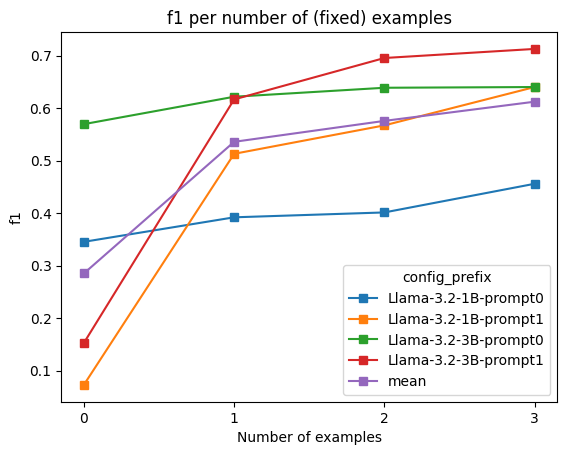

In [35]:

metric_per_shot.plot(
    kind="line", marker="s", xticks=metric_per_shot.index,
    xlabel="Number of examples", ylabel=metric, 
    title=f"{metric} per number of (fixed) examples"
)

<Axes: title={'center': 'f1 for each example'}, xlabel='Number of examples', ylabel='f1'>

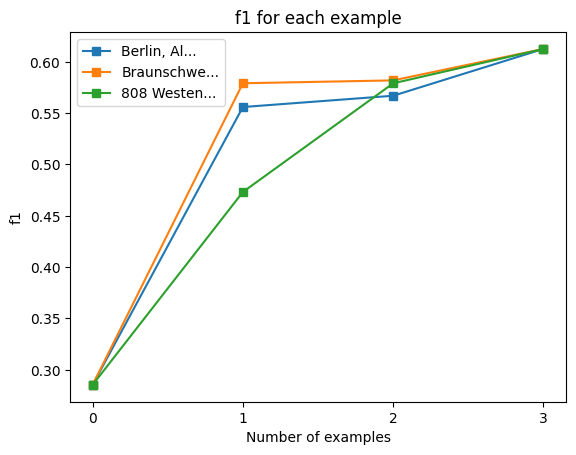

In [36]:
metric_per_example_per_shot.plot(
    kind="line", marker="s", xticks=metric_per_shot.index,
    xlabel="Number of examples", ylabel=metric, 
    title=f"{metric} for each example"
)

In [37]:
metric_per_column = pd.DataFrame(index=model_statistics.index, columns=COLS_TO_PREDICT)
for col in COLS_TO_PREDICT:
    for config in model_statistics.index:
        preds = preds_per_config[preds_per_config["config_name"] == config]
        if col in preds.columns:
            value = compare_preds(preds, bzkopen_val, target_columns=[col])[metric]
            metric_per_column.at[config, col] = value
        else:
            metric_per_column.at[config, col] = pd.NA
print(f"Per-column {metric} scores:")
metric_per_column

Per-column f1 scores:


,HouseNumber,StreetName,City,State,Country
libpostal,0.75,0.604651,0.432432,0.444444,0.428571
libpostal-expanded,0.7,0.238095,0.525253,0.333333,0.584615
deepparse-bpemb,0.704225,0.036036,0.289593,0.0,0.12
deepparse-fasttext,0.625,0.081633,0.393013,0.0,0.233333
deepparse-bpemb-attention,0.130435,0.021978,0.011765,0.0,0.176991
deepparse-fasttext-attention,0.392857,0.014184,0.11828,0.0,0.226415
xlm-roberta-large-address-parser,0.843373,0.674157,0.478261,0.0,0.773333
xlm-roberta-large-address-parser-word-avg,0.843373,0.712644,0.519824,0.0,0.756757
xlm-roberta-large-address-parser-word-max,0.843373,0.72093,0.508929,0.0,0.72973
Llama-3.2-1B-prompt0-fixed3shot,0.3625,0.301205,0.713693,0.117647,0.042553


<Axes: title={'center': 'f1 per number of (fixed) examples'}, xlabel='Number of examples', ylabel='f1'>

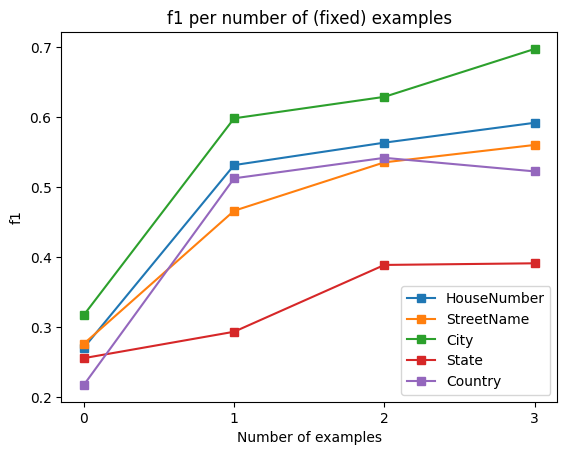

In [38]:
metric_per_column_per_shot = pd.DataFrame(
    index=pd.MultiIndex.from_product([model_statistics_nshots.index, metric_per_shot.index]),
    columns=COLS_TO_PREDICT
)
for col in COLS_TO_PREDICT:
    for config in model_statistics_nshots.index:
        preds = preds_per_nshots[preds_per_nshots["config_name"] == config]
        if col in preds.columns:
            value = compare_preds(preds, bzkopen_val, target_columns=[col])[metric]
            n_shots, example_indices, model_name = get_n_shots(config)
            if n_shots is not None:
                metric_per_column_per_shot.at[(config, n_shots), col] = value
        else:
            metric_per_column_per_shot.at[(config, 0), col] = pd.NA

metric_per_column_per_shot = metric_per_column_per_shot.groupby(level=1).mean()
metric_per_column_per_shot.plot(
    kind="line", marker="s", xticks=metric_per_shot.index,
    xlabel="Number of examples", ylabel=metric, 
    title=f"{metric} per number of (fixed) examples"
)

In [39]:
bzk_fields = bzkopen_val["field"].unique()
print(f"bzk_fields: {bzk_fields}")
metric_per_bzk_field = pd.DataFrame(index=model_statistics.index, columns=bzk_fields)

for field in bzk_fields:
    mask = bzkopen_val["field"] == field
    subset = bzkopen_val[mask]
    for config in model_statistics.index:
        preds = preds_per_config[preds_per_config["config_name"] == config]
        value = compare_preds(preds[mask], subset, target_columns=COLS_TO_PREDICT)[metric]
        metric_per_bzk_field.at[config, field] = value
print(f"Per-BZK-field {metric} scores:")
metric_per_bzk_field

bzk_fields: <StringArray>
['ApplicantCurrentAddress',        'VictimBirthPlace',
     'ApplicantBirthPlace',        'VictimDeathPlace']
Length: 4, dtype: str
Per-BZK-field f1 scores:


,ApplicantCurrentAddress,VictimBirthPlace,ApplicantBirthPlace,VictimDeathPlace
libpostal,0.528,0.526316,0.542373,0.4
libpostal-expanded,0.416988,0.55814,0.640625,0.888889
deepparse-bpemb,0.220532,0.425532,0.304348,0.4
deepparse-fasttext,0.265683,0.666667,0.380282,0.363636
deepparse-bpemb-attention,0.0625,0.064516,0.09901,0.0
deepparse-fasttext-attention,0.14094,0.208333,0.130435,0.0
xlm-roberta-large-address-parser,0.610169,0.577778,0.6,0.727273
xlm-roberta-large-address-parser-word-avg,0.616438,0.636364,0.652174,0.8
xlm-roberta-large-address-parser-word-max,0.616438,0.604651,0.637037,0.8
Llama-3.2-1B-prompt0-fixed3shot,0.556634,0.318182,0.326531,0.347826


<Axes: title={'center': 'f1 per number of (fixed) examples'}, xlabel='Number of examples', ylabel='f1'>

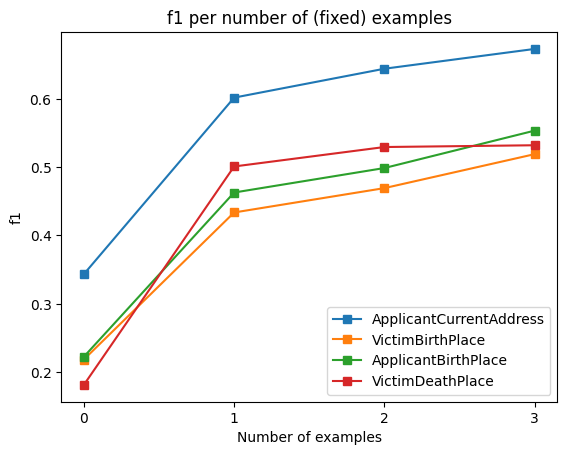

In [40]:
metric_per_bzk_field_per_shot =  pd.DataFrame(
    index=pd.MultiIndex.from_product([model_statistics_nshots.index, metric_per_shot.index]),
    columns=bzk_fields
)

for field in bzk_fields:
    mask = bzkopen_val["field"] == field
    subset = bzkopen_val[mask]
    for config in model_statistics_nshots.index:
        preds = preds_per_nshots[preds_per_nshots["config_name"] == config]
        value = compare_preds(preds[mask], subset, target_columns=COLS_TO_PREDICT)[metric]
        n_shots, example_indices, model_name = get_n_shots(config)
        if n_shots is not None:
            metric_per_bzk_field_per_shot.at[(config, n_shots), field] = value

metric_per_bzk_field_per_shot = metric_per_bzk_field_per_shot.groupby(level=1).mean()
metric_per_bzk_field_per_shot.plot(
    kind="line", marker="s", xticks=metric_per_shot.index,
    xlabel="Number of examples", ylabel=metric, 
    title=f"{metric} per number of (fixed) examples"
)